# Entrega 1 - Pipeline Base con PyTorch

## Objetivo

Implementar un pipeline básico de clasificación utilizando PyTorch sobre un conjunto de datos simple.

Este notebook tiene como objetivo construir la infraestructura de entrenamiento que será reutilizada posteriormente en el proyecto de clasificación de noticias.

No implementa aún técnicas de Procesamiento del Lenguaje Natural, sino que desarrolla los componentes generales de entrenamiento, validación y evaluación requeridos por la primera entrega.

In [1]:
# ==========================================
# Librerías estándar
# ==========================================

import random

# ==========================================
# Librerías numéricas
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# PyTorch
# ==========================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# Scikit-learn
# ==========================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 1. Configuración del entorno y reproducibilidad

In [2]:
# Detectar automáticamente el dispositivo disponible
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Dispositivo seleccionado: {device}")

Dispositivo seleccionado: cpu


In [3]:
# Semilla general del proyecto
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Semilla configurada: {SEED}")

Semilla configurada: 42


## 2. Carga del conjunto de datos

In [4]:
# Cargar el conjunto de datos Iris
iris = load_iris()

# Variables predictoras
X = iris.data

# Variable objetivo
y = iris.target

In [5]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [7]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [8]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [9]:
# Crear un DataFrame para inspeccionar el dataset
df = pd.DataFrame(X, columns=iris.feature_names)

# Agregar la clase objetivo
df["target"] = y

# Mostrar las primeras filas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Preparación del conjunto de datos

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

In [11]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (120, 4)
Prueba: (30, 4)


In [12]:
# Separar una porción del conjunto de entrenamiento para validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (96, 4)
Validación: (24, 4)
Prueba: (30, 4)


### 3.1 Estandarización de las variables

In [13]:
# Crear el estandarizador
scaler = StandardScaler()

# Aprender media y desvío únicamente con entrenamiento
X_train = scaler.fit_transform(X_train)

# Aplicar la misma transformación a validación y prueba
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [14]:
print("Media aproximada de X_train:", X_train.mean(axis=0))
print("Desvío aproximado de X_train:", X_train.std(axis=0))

Media aproximada de X_train: [3.61978965e-16 1.15648232e-16 7.28583860e-16 2.92300906e-16]
Desvío aproximado de X_train: [1. 1. 1. 1.]


## 4. Conversión a tensores

In [15]:
# Convertir variables predictoras a tensores float32
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Convertir etiquetas a tensores long
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [16]:
print("X_train:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train:", y_train_tensor.shape, y_train_tensor.dtype)

X_train: torch.Size([96, 4]) torch.float32
y_train: torch.Size([96]) torch.int64


## 5. Creación de datasets y dataloaders

In [17]:
# Agrupar variables y etiquetas
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [18]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [19]:
X_batch, y_batch = next(iter(train_loader))

print("X_batch:", X_batch.shape)
print("y_batch:", y_batch.shape)

X_batch: torch.Size([16, 4])
y_batch: torch.Size([16])


## 6. Arquitectura del modelo

In [20]:
# Definir la arquitectura de la red neuronal
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

# Mover el modelo al dispositivo seleccionado
model = model.to(device)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)


In [21]:
# Mover un lote al dispositivo
X_batch = X_batch.to(device)

# Realizar una pasada hacia adelante
outputs = model(X_batch)

print("Entrada:", X_batch.shape)
print("Salida:", outputs.shape)
print(outputs[:3])

Entrada: torch.Size([16, 4])
Salida: torch.Size([16, 3])
tensor([[-0.3852,  0.1292, -0.2227],
        [-0.3620,  0.1168, -0.2944],
        [-0.3177,  0.0959, -0.4561]], grad_fn=<SliceBackward0>)


## 7. Función de pérdida y optimizador

In [22]:
# Función de pérdida para clasificación multiclase
criterion = nn.CrossEntropyLoss()

# Optimizador
LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Función de pérdida:", criterion)
print("Optimizador:", optimizer)

Función de pérdida: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [23]:
# Recuperar un lote completo
X_batch, y_batch = next(iter(train_loader))

# Mover datos al dispositivo
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

# Forward pass
outputs = model(X_batch)

# Calcular la pérdida inicial
loss = criterion(outputs, y_batch)

print("Forma de los logits:", outputs.shape)
print("Forma de las etiquetas:", y_batch.shape)
print("Pérdida inicial:", loss.item())

Forma de los logits: torch.Size([16, 3])
Forma de las etiquetas: torch.Size([16])
Pérdida inicial: 1.170160174369812


## 8. Ciclo de entrenamiento

In [24]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Reiniciar gradientes acumulados
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calcular pérdida
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Actualizar pesos
        optimizer.step()

        # Acumular pérdida
        total_loss += loss.item() * X_batch.size(0)

        # Obtener clase predicha
        predictions = outputs.argmax(dim=1)

        # Acumular aciertos
        total_correct += (predictions == y_batch).sum().item()
        total_samples += y_batch.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

## 9. Ciclo de validación

In [25]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)

            # Calcular pérdida
            loss = criterion(outputs, y_batch)

            # Acumular pérdida
            total_loss += loss.item() * X_batch.size(0)

            # Obtener clase predicha
            predictions = outputs.argmax(dim=1)

            # Acumular aciertos
            total_correct += (predictions == y_batch).sum().item()
            total_samples += y_batch.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

## 10. Entrenamiento por épocas

In [26]:
EPOCHS = 200

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_accuracy = evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Época {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_accuracy:.4f}"
    )

Época 01/200 | Train loss: 1.1798 | Train acc: 0.3333 | Val loss: 1.1493 | Val acc: 0.4167
Época 02/200 | Train loss: 1.1523 | Train acc: 0.3333 | Val loss: 1.1249 | Val acc: 0.4583
Época 03/200 | Train loss: 1.1274 | Train acc: 0.3333 | Val loss: 1.1003 | Val acc: 0.4583
Época 04/200 | Train loss: 1.1016 | Train acc: 0.3333 | Val loss: 1.0760 | Val acc: 0.4583
Época 05/200 | Train loss: 1.0782 | Train acc: 0.3333 | Val loss: 1.0515 | Val acc: 0.4583
Época 06/200 | Train loss: 1.0540 | Train acc: 0.3958 | Val loss: 1.0272 | Val acc: 0.4583
Época 07/200 | Train loss: 1.0307 | Train acc: 0.4167 | Val loss: 1.0029 | Val acc: 0.4583
Época 08/200 | Train loss: 1.0052 | Train acc: 0.4583 | Val loss: 0.9790 | Val acc: 0.5417
Época 09/200 | Train loss: 0.9801 | Train acc: 0.5104 | Val loss: 0.9544 | Val acc: 0.6667
Época 10/200 | Train loss: 0.9545 | Train acc: 0.6146 | Val loss: 0.9294 | Val acc: 0.7083
Época 11/200 | Train loss: 0.9296 | Train acc: 0.6771 | Val loss: 0.9037 | Val acc: 0.8750

## 11. Curvas de entrenamiento

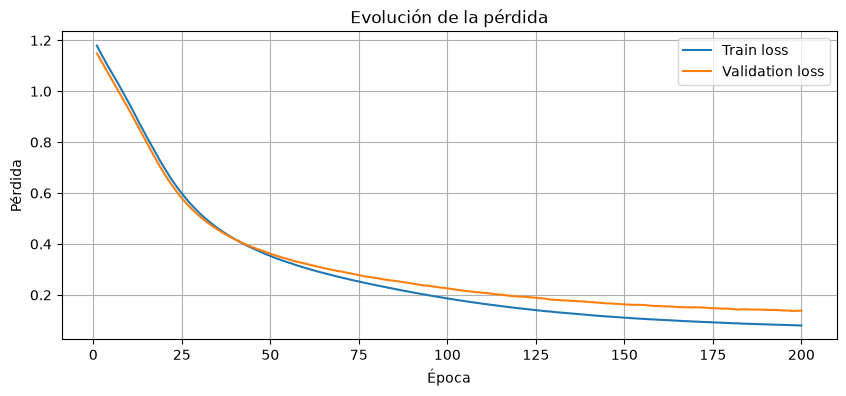

In [27]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(True)
plt.show()

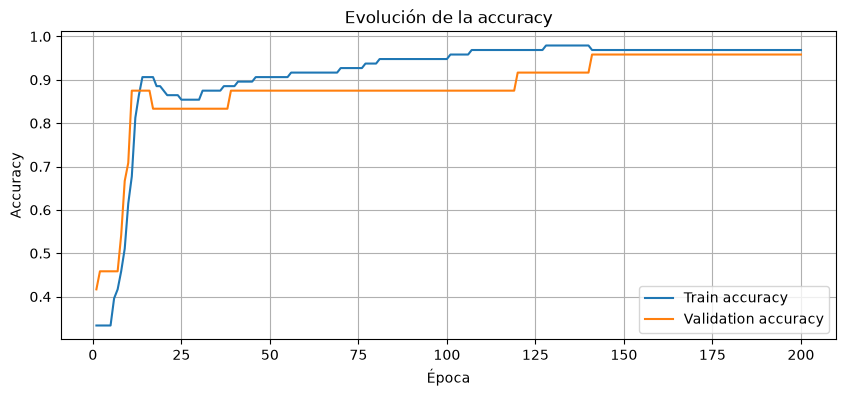

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución de la accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 12. Evaluación final sobre test

In [29]:
test_loss, test_accuracy = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.1296
Test accuracy: 0.9667


## 13. Matriz de confusión

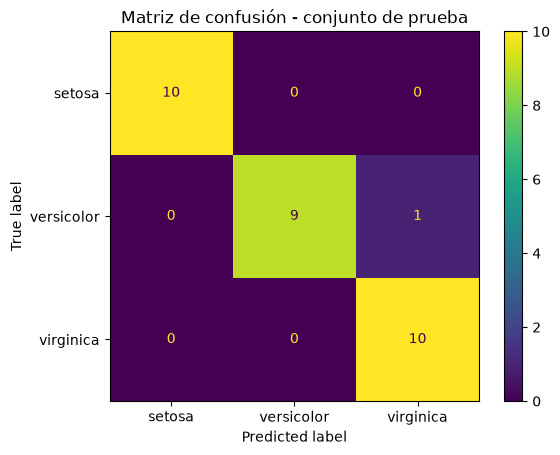

In [30]:
# Obtener predicciones sobre el conjunto de prueba
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

# Calcular matriz de confusión
cm = confusion_matrix(all_targets, all_predictions)

# Visualizar
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("Matriz de confusión - conjunto de prueba")
plt.show()

In [31]:
print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 14. Conclusión
Se implementó correctamente un pipeline de clasificación utilizando PyTorch sobre el conjunto de datos Iris.

Durante las 200 épocas de entrenamiento se observó una disminución sostenida de la pérdida y un incremento progresivo de la accuracy tanto en entrenamiento como en validación, alcanzando una convergencia estable sin evidencias significativas de sobreajuste.

La evaluación sobre el conjunto de prueba obtuvo una accuracy del 96,67 %, lo que indica una adecuada capacidad de generalización.

La matriz de confusión mostró una clasificación perfecta para las clases Setosa y Virginica. Sólo una observación de la clase Versicolor fue clasificada incorrectamente como Virginica, comportamiento consistente con la mayor similitud existente entre ambas especies dentro del conjunto de datos Iris.

El notebook implementa satisfactoriamente todas las etapas fundamentales de un pipeline de entrenamiento en PyTorch: preparación de datos, entrenamiento, validación y evaluación final.

## 15. Persistencia de objetos

In [34]:
# Guardar el modelo

import os
import torch

os.makedirs("../outputs/models", exist_ok=True)

torch.save(
    model.state_dict(),
    "../outputs/models/modelo_iris.pth"
)

print("✅ Modelo guardado.")

✅ Modelo guardado.


In [35]:
# Guardar el historial

import json

os.makedirs("../outputs/metrics", exist_ok=True)

with open("../outputs/metrics/history.json", "w") as f:
    json.dump(history, f, indent=4)

print("✅ Historial guardado.")

✅ Historial guardado.


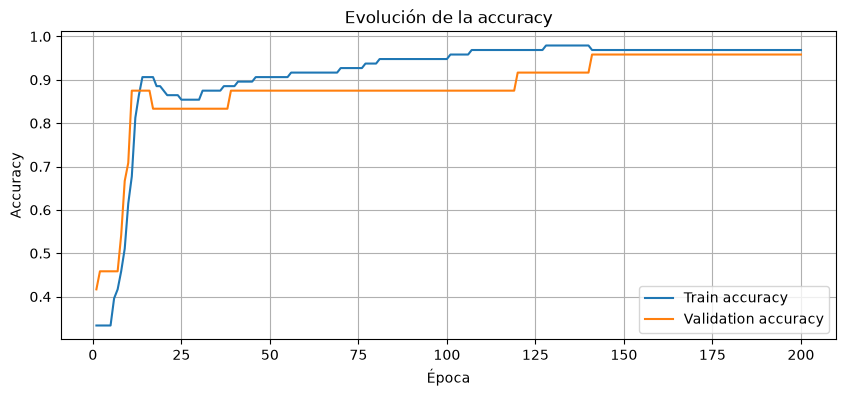

In [41]:
# Curva de accuracy

fig = plt.figure(figsize=(10, 4))

plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución de la accuracy")
plt.legend()
plt.grid(True)

fig.savefig(
    "../outputs/figures/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

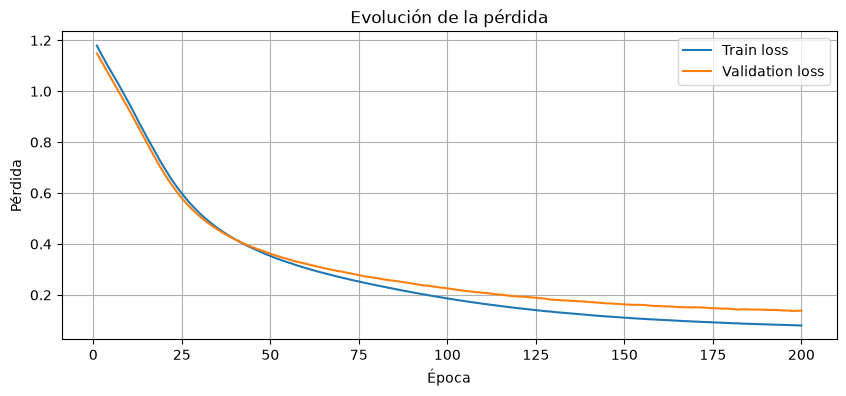

In [40]:
# Curva de pérdida

os.makedirs("../outputs/figures", exist_ok=True)

epochs = range(1, EPOCHS + 1)

fig = plt.figure(figsize=(10, 4))

plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(True)

fig.savefig(
    "../outputs/figures/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

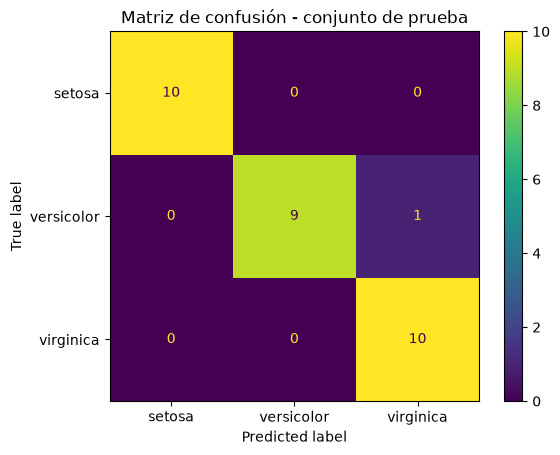

In [42]:
# Matriz de confusión

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("Matriz de confusión - conjunto de prueba")

display.figure_.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()